# Khai triển chuỗi Fourier: FS và DTFS

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dangquanghieu/tinhieu-hethong-notebooks/blob/main/notebooks/04_khai-trien-chuoi-fourier.ipynb)

Notebook minh họa cách biểu diễn tín hiệu tuần hoàn bằng chuỗi Fourier liên tục (FS) và chuỗi Fourier cho tín hiệu rời rạc (DTFS).

## Mục tiêu

- Tính và biểu diễn hệ số chuỗi Fourier của một xung chữ nhật tuần hoàn.
- Quan sát tổng hữu hạn các thành phần hài và biến động gần điểm gián đoạn.
- Tính hệ số DTFS bằng tổng trực tiếp và đối chiếu với `numpy.fft.fft`.
- Tái tạo một chu kỳ dãy từ hệ số DTFS và nhận biết tính tuần hoàn.


## Tóm tắt lý thuyết

Với tín hiệu liên tục tuần hoàn $x(t)$ có chu kỳ $T$ và tần số góc cơ bản $\Omega_0=2\pi/T$, khai triển FS và hệ số phổ là

$$
x(t)=\sum_{k=-\infty}^{\infty}c_k e^{jk\Omega_0t},
\qquad
c_k=\frac{1}{T}\int_{t_0}^{t_0+T}x(t)e^{-jk\Omega_0t}\,dt.
$$

Hai cận tích phân có thể chọn tùy ý miễn là khoảng tích phân phủ đúng một chu kỳ. Với xung chữ nhật đối xứng quanh gốc, có độ rộng $T_0$, hệ số là

$$
c_k=\frac{T_0}{T}\operatorname{sinc}\left(k\frac{T_0}{T}\right),
$$

trong đó $\operatorname{sinc}(u)=\sin(\pi u)/(\pi u)$.

Với dãy tuần hoàn $\tilde{x}[n]$ có chu kỳ $N$ mẫu, một chu kỳ của khai triển DTFS là

$$
\tilde{x}[n]=\sum_{k=0}^{N-1}\tilde{c}_k e^{j(2\pi/N)kn},
\qquad
\tilde{c}_k=\frac{1}{N}\sum_{n=0}^{N-1}\tilde{x}[n]e^{-j(2\pi/N)kn}.
$$

Theo quy ước này, phương trình tổng hợp không có hệ số $1/N$, còn hệ số phân tích có $1/N$. Dãy hệ số $\tilde{c}_k$ tuần hoàn theo $k$ với chu kỳ $N$.

*Xem thêm: [sách Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht), Chương 3, mục 3.1 (Chuỗi Fourier cho tín hiệu liên tục, tuần hoàn) và mục 3.2 (Chuỗi Fourier cho tín hiệu rời rạc theo thời gian).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Cấu hình màu sắc và hình vẽ dùng chung cho toàn notebook.
COLORS = {
    "signal": "#0072B2",
    "spectrum": "#D55E00",
    "reconstruction": "#009E73",
    "reference": "#CC79A7",
    "axis": "#555555",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 1.8,
})

In [2]:
# Các hàm dưới đây thống nhất cách vẽ tín hiệu liên tục và dãy rời rạc.
def stem(ax, index, values, color, label=None):
    markers, stems, baseline = ax.stem(
        index, values, basefmt=" ", label=label
    )
    markers.set_color(color)
    stems.set_color(color)
    ax.axhline(0, color=COLORS["axis"], linewidth=0.8)


def style_continuous(ax, title, xlabel=r"Thời gian $t$ (s)", ylabel="Biên độ"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def style_discrete(ax, title, xlabel=r"Chỉ số $n$ (mẫu)", ylabel="Biên độ"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color=COLORS["axis"], linewidth=0.8)


def style_phase(ax):
    """Dùng các mốc pha theo bội của pi trên trục tung."""
    ax.set_yticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
    )


## Minh họa 1 — Hệ số FS của xung chữ nhật tuần hoàn

Tín hiệu có biên độ 1 trong khoảng $-T_0/2<t<T_0/2$ của mỗi chu kỳ và bằng 0 ở phần còn lại. Hình biểu diễn một số chu kỳ cùng phổ biên độ và phổ pha. Vì xung được đặt đối xứng quanh $t=0$, các hệ số $c_k$ là số thực. Pha của hệ số bằng 0 hoặc $\pi$ khi hệ số khác 0; tại hệ số bằng 0, pha không xác định.


T0/T = 0.30
Kiểm tra hệ số giải tích với tích phân hình thang: True


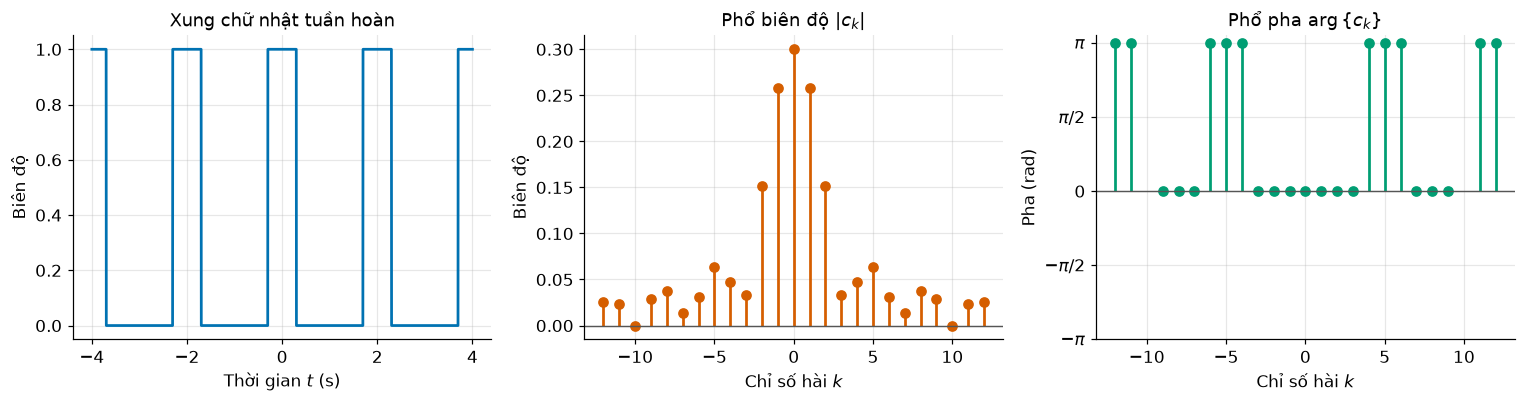

In [3]:
# --- Tạo tín hiệu: dựng x(t) trên trục thời gian t tường minh ---
T = 2.0
T0 = 0.6
t = np.linspace(-2 * T, 2 * T, 2401)
time_in_period = (t + T / 2) % T - T / 2
x_t = (np.abs(time_in_period) < T0 / 2).astype(float)

# --- Tính toán: hệ số FS theo công thức (T0/T)*sinc(k*T0/T) ---
k = np.arange(-12, 13)
c_k = (T0 / T) * np.sinc(k * T0 / T)
magnitude = np.abs(c_k)
phase = np.angle(c_k)
phase[magnitude < 1e-12] = np.nan

# Đối chiếu một vài hệ số với tích phân số trên đúng một chu kỳ.
t_period = np.linspace(-T / 2, T / 2, 60001)
period_position = (t_period + T / 2) % T - T / 2
x_period = (np.abs(period_position) < T0 / 2).astype(float)
k_check = np.array([-3, 0, 2])
c_numeric = np.array([
    trapezoid(x_period * np.exp(-1j * 2 * np.pi * ki * t_period / T), t_period) / T
    for ki in k_check
])
assert np.allclose(c_numeric, (T0 / T) * np.sinc(k_check * T0 / T), atol=2e-5)

# --- Vẽ ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(t, x_t, color=COLORS["signal"])
style_continuous(axes[0], "Xung chữ nhật tuần hoàn")

stem(axes[1], k, magnitude, COLORS["spectrum"])
style_discrete(axes[1], r"Phổ biên độ $|c_k|$", xlabel=r"Chỉ số hài $k$", ylabel="Biên độ")

stem(axes[2], k, phase, COLORS["reconstruction"])
style_discrete(axes[2], r"Phổ pha $\arg\{c_k\}$", xlabel=r"Chỉ số hài $k$", ylabel="Pha (rad)")
style_phase(axes[2])
plt.tight_layout()

print(f"T0/T = {T0 / T:.2f}")
print("Kiểm tra hệ số giải tích với tích phân hình thang:", np.allclose(c_numeric, (T0 / T) * np.sinc(k_check * T0 / T), atol=2e-5))


**Nhận xét.** Thành phần một chiều $c_0=T_0/T$. Độ lớn các hệ số giảm theo dạng hàm sinc. Pha chỉ nhận 0 hoặc $\pi$ (theo quy ước pha chính) vì các hệ số là số thực; các hệ số âm ứng với pha $\pi$.

## Minh họa 2 — Tổng hữu hạn các thành phần hài

Ta cộng các số hạng từ $k=-K$ đến $k=K$. Đồ thị trái cho thấy dạng sóng trên nhiều chu kỳ; đồ thị phải phóng to một điểm gián đoạn. Khi tăng $K$, sai khác xa điểm gián đoạn giảm và dao động gần cạnh xung tập trung hơn. Tại chính điểm gián đoạn, tổng chuỗi hội tụ về trung bình của giới hạn hai phía.

Giá trị tổng hữu hạn tại cạnh với K = 1, 3, 10, 30: [0.602731 0.446816 0.488522 0.496149]
Giá trị với |k|≤1000 tại cạnh: 0.499884 (giới hạn trung bình = 0.5)
Công suất từ miền thời gian: 0.300000; tổng Parseval đến |k|=100: 0.298987; giá trị đúng: 0.300000


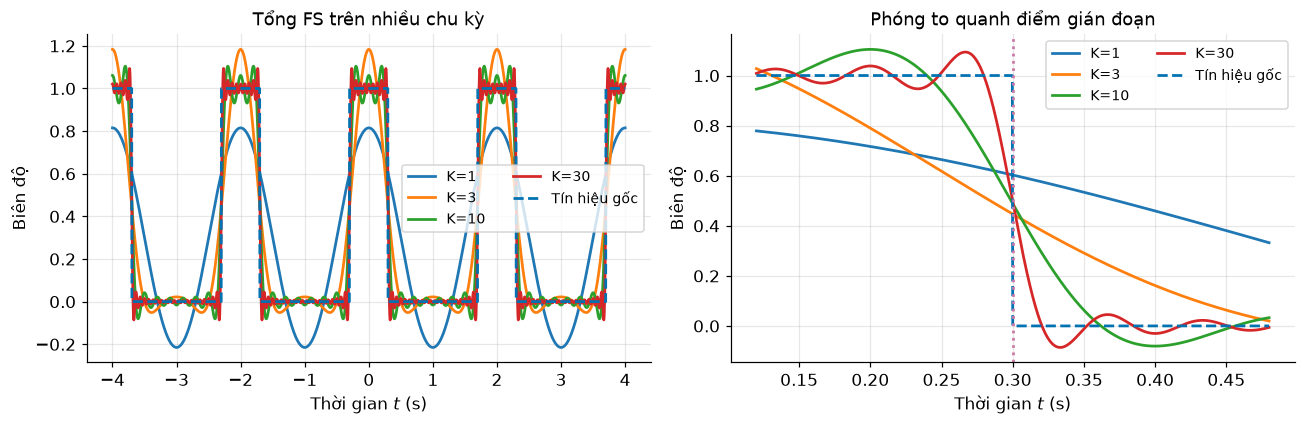

In [4]:
# --- Tạo tín hiệu: lấy mẫu dày quanh cạnh xung tại t=T0/2 ---
t_zoom = np.linspace(T0 / 2 - 0.18, T0 / 2 + 0.18, 1201)
time_zoom_in_period = (t_zoom + T / 2) % T - T / 2
x_zoom = (np.abs(time_zoom_in_period) < T0 / 2).astype(float)

# --- Tính toán: tổng các thành phần hài với các K khác nhau ---
harmonic_limits = [1, 3, 10, 30]
approximations = {}
for K in harmonic_limits:
    k_partial = np.arange(-K, K + 1)
    c_partial = (T0 / T) * np.sinc(k_partial * T0 / T)
    # Mảng mũ có kích thước (số hài, số thời điểm); cộng theo trục các hài.
    basis = np.exp(1j * 2 * np.pi * k_partial[:, None] * t[None, :] / T)
    approximations[K] = np.sum(c_partial[:, None] * basis, axis=0).real

k_edge = np.arange(-1000, 1001)
edge_value = np.sum((T0 / T) * np.sinc(k_edge * T0 / T) * np.exp(1j * 2 * np.pi * k_edge * (T0 / 2) / T)).real
edge_values_displayed = []
for K in harmonic_limits:
    k_edge_partial = np.arange(-K, K + 1)
    value = np.sum((T0 / T) * np.sinc(k_edge_partial * T0 / T) * np.exp(1j * 2 * np.pi * k_edge_partial * (T0 / 2) / T)).real
    edge_values_displayed.append(value)
assert np.allclose(edge_value, 0.5, atol=2e-4)

# Kiểm chứng công suất trung bình của tín hiệu và xấp xỉ Parseval.
power_time = trapezoid(x_period ** 2, t_period) / T
k_power = np.arange(-100, 101)
power_spectrum = np.sum(np.abs((T0 / T) * np.sinc(k_power * T0 / T)) ** 2)
assert np.allclose(power_time, T0 / T, atol=2e-5)

# --- Vẽ ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for K in harmonic_limits:
    axes[0].plot(t, approximations[K], label=f"K={K}")
axes[0].plot(t, x_t, color=COLORS["signal"], linestyle="--", label="Tín hiệu gốc")
style_continuous(axes[0], "Tổng FS trên nhiều chu kỳ")
axes[0].legend(ncol=2)

for K in harmonic_limits:
    k_partial = np.arange(-K, K + 1)
    c_partial = (T0 / T) * np.sinc(k_partial * T0 / T)
    basis_zoom = np.exp(1j * 2 * np.pi * k_partial[:, None] * t_zoom[None, :] / T)
    x_approx_zoom = np.sum(c_partial[:, None] * basis_zoom, axis=0).real
    axes[1].plot(t_zoom, x_approx_zoom, label=f"K={K}")
axes[1].plot(t_zoom, x_zoom, color=COLORS["signal"], linestyle="--", label="Tín hiệu gốc")
axes[1].axvline(T0 / 2, color=COLORS["reference"], linestyle=":")
style_continuous(axes[1], "Phóng to quanh điểm gián đoạn")
axes[1].legend(ncol=2)
plt.tight_layout()

print("Giá trị tổng hữu hạn tại cạnh với K = 1, 3, 10, 30:", np.round(edge_values_displayed, 6))
print(f"Giá trị với |k|≤1000 tại cạnh: {edge_value:.6f} (giới hạn trung bình = 0.5)")
print(f"Công suất từ miền thời gian: {power_time:.6f}; tổng Parseval đến |k|=100: {power_spectrum:.6f}; giá trị đúng: {T0 / T:.6f}")


**Nhận xét.** Tổng hữu hạn bám sát tín hiệu gốc hơn khi tăng số thành phần hài. Gần cạnh xung xuất hiện dao động vượt mức; vùng dao động hẹp dần nhưng không biến mất hoàn toàn. Tại cạnh, tổng bằng $0.5$, là trung bình của mức 0 và mức 1. Công suất trung bình theo thời gian và tổng bình phương hệ số phổ tiến gần giá trị đúng $T_0/T$ theo quan hệ Parseval.

## Minh họa 3 — Phân tích và tổng hợp DTFS

Dãy một chu kỳ lấy theo ví dụ trong giáo trình: $\tilde{x}[n]=\{-3,2,-1,4\}$ với mẫu đầu tiên ứng với $n=0$. Ta tính hệ số bằng tổng DTFS, đối chiếu với FFT đã chia cho $N$, rồi dùng phương trình tổng hợp để khôi phục các mẫu.

Ở đây, `np.fft.fft` dùng thuật toán nhanh (FFT) để tính biến đổi Fourier rời rạc (DFT). DFT sẽ được học trong môn Xử lý tín hiệu số; ở minh họa này, FFT chỉ dùng để đối chiếu hệ số DTFS.

Các hệ số DTFS trong một chu kỳ: [ 0.5+0.j  -0.5+0.5j -2.5-0.j  -0.5-0.5j]
Tổng trực tiếp khớp fft(x)/N: True
Sai số tái tạo lớn nhất: 5.900916318210353e-16


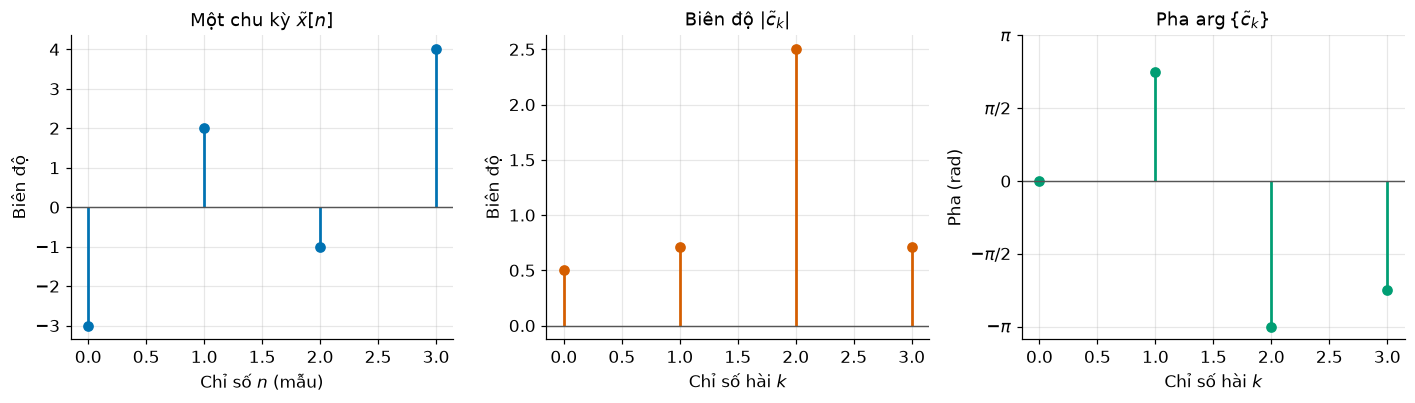

In [5]:
# --- Tạo tín hiệu: một chu kỳ của dãy tuần hoàn ---
N = 4
n = np.arange(N)
x_periodic = np.array([-3, 2, -1, 4], dtype=float)
k = np.arange(N)

# --- Tính toán: tổng trực tiếp phân tích và phương trình tổng hợp ---
# Ma trận cơ sở có kích thước (N chỉ số k, N mẫu n).
analysis_basis = np.exp(-1j * 2 * np.pi * k[:, None] * n[None, :] / N)
c_tilde = analysis_basis @ x_periodic / N
c_tilde_fft = np.fft.fft(x_periodic) / N
assert np.allclose(c_tilde, c_tilde_fft)

synthesis_basis = np.exp(1j * 2 * np.pi * k[:, None] * n[None, :] / N)
x_reconstructed = np.sum(c_tilde[:, None] * synthesis_basis, axis=0)
assert np.allclose(x_reconstructed, x_periodic)

# --- Vẽ ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
stem(axes[0], n, x_periodic, COLORS["signal"])
style_discrete(axes[0], r"Một chu kỳ $\tilde{x}[n]$")

stem(axes[1], k, np.abs(c_tilde), COLORS["spectrum"])
style_discrete(axes[1], r"Biên độ $|\tilde{c}_k|$", xlabel=r"Chỉ số hài $k$")

stem(axes[2], k, np.angle(c_tilde), COLORS["reconstruction"])
style_discrete(axes[2], r"Pha $\arg\{\tilde{c}_k\}$", xlabel=r"Chỉ số hài $k$", ylabel="Pha (rad)")
style_phase(axes[2])
plt.tight_layout()

print("Các hệ số DTFS trong một chu kỳ:", np.round(c_tilde, 4))
print("Tổng trực tiếp khớp fft(x)/N:", np.allclose(c_tilde, c_tilde_fft))
print("Sai số tái tạo lớn nhất:", np.max(np.abs(x_reconstructed - x_periodic)))


**Nhận xét.** Hệ số $\tilde{c}_0=0.5$ bằng giá trị trung bình của bốn mẫu. Tổng trực tiếp khớp với `np.fft.fft(x)/N`; hệ số $1/N$ là cần thiết trong bước phân tích theo quy ước của giáo trình. Tổng hợp không chia thêm cho $N$ và tái tạo đúng các mẫu của một chu kỳ.

## Minh họa 4 — Hệ số DTFS tuần hoàn theo $k$

Các thành phần $e^{j(2\pi/N)(k+N)n}$ và $e^{j(2\pi/N)kn}$ giống nhau tại mọi chỉ số nguyên $n$. Do đó, hệ số DTFS lặp lại sau mỗi $N$ chỉ số hài. Hình dưới mở rộng hệ số của ví dụ trước qua nhiều chu kỳ để thấy tính tuần hoàn này.

Chu kỳ của hệ số DTFS theo k: N = 4
Các thành phần hài cách nhau N cho cùng giá trị: True


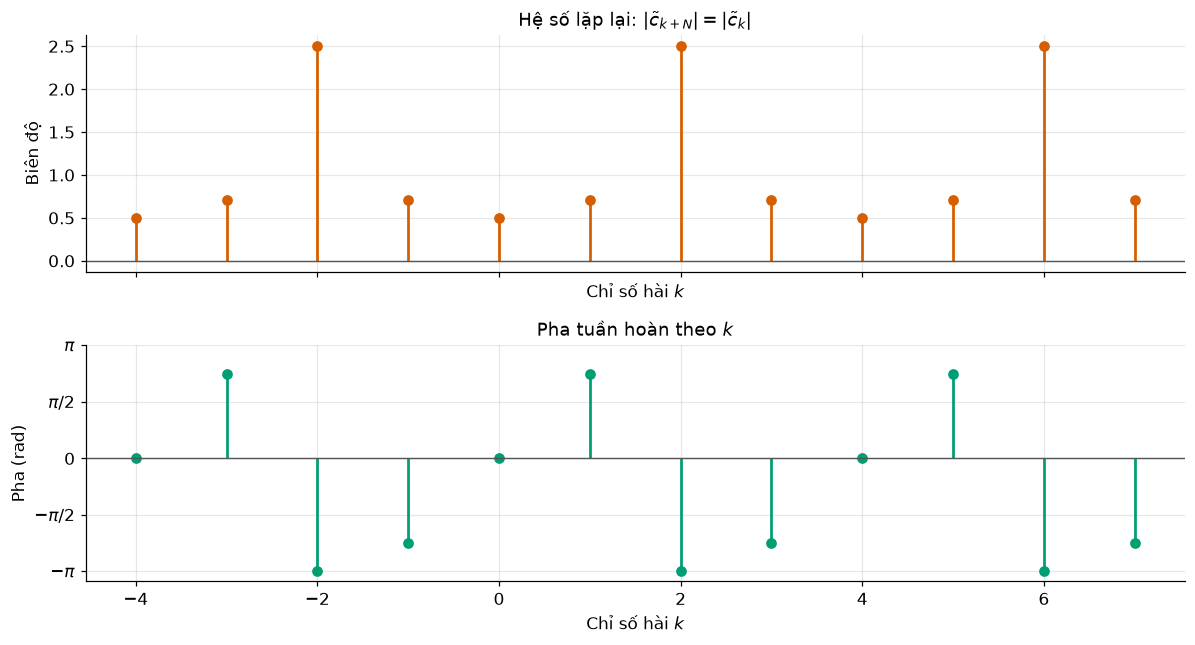

In [6]:
# --- Tạo chỉ số tần số: mở rộng ba chu kỳ của dãy hệ số ---
k_extended = np.arange(-N, 2 * N)
c_extended = c_tilde[k_extended % N]

# --- Kiểm chứng tính tuần hoàn theo k ---
assert np.allclose(c_extended[N:], c_extended[:-N])
basis_k = np.exp(1j * 2 * np.pi * k_extended[:, None] * n[None, :] / N)
basis_k_shifted = np.exp(1j * 2 * np.pi * (k_extended + N)[:, None] * n[None, :] / N)
assert np.allclose(basis_k, basis_k_shifted)

# --- Vẽ ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
stem(axes[0], k_extended, np.abs(c_extended), COLORS["spectrum"])
style_discrete(axes[0], r"Hệ số lặp lại: $|\tilde{c}_{k+N}|=|\tilde{c}_k|$",
               xlabel=r"Chỉ số hài $k$", ylabel="Biên độ")

stem(axes[1], k_extended, np.angle(c_extended), COLORS["reconstruction"])
style_discrete(axes[1], r"Pha tuần hoàn theo $k$",
               xlabel=r"Chỉ số hài $k$", ylabel="Pha (rad)")
style_phase(axes[1])
plt.tight_layout()

print(f"Chu kỳ của hệ số DTFS theo k: N = {N}")
print("Các thành phần hài cách nhau N cho cùng giá trị:", np.allclose(basis_k, basis_k_shifted))


**Nhận xét.** Cả biên độ lẫn pha của hệ số lặp lại sau mỗi $N=4$ chỉ số. Sự lặp lại xuất phát từ tính đồng nhất của các thành phần hài khi thay $k$ bằng $k+N$; vì vậy chỉ cần lưu một chu kỳ gồm $N$ hệ số.

## Câu hỏi suy ngẫm

1. Nếu tăng độ rộng xung $T_0$ nhưng giữ nguyên chu kỳ $T$, phổ biên độ FS thay đổi như thế nào?
2. Vì sao tổng FS của tín hiệu có điểm gián đoạn tiến về trung bình của hai giới hạn tại điểm đó?
3. Hệ số nào trong DTFS biểu diễn giá trị trung bình của một chu kỳ dãy? Vì sao?
4. Điều gì sẽ sai trong phép tái tạo nếu chia thêm cho $N$ ở phương trình tổng hợp DTFS?
5. Vì sao hệ số DTFS tại $k$ và $k+N$ bằng nhau dù các chỉ số hài khác nhau?
